# Arousal Prediction — v6

## Changes from v5

| v5 bug | Fix |
|--------|-----|
| Test normalized with training global stats (broke per-person baselines) | Test normalized **per-pid using test pid's own data** |
| Regression + rounding (optimizes MAE, not accuracy) | **Direct classifier** (RF + LGB multiclass) |
| Count features removed (hurt generalization) | Count features **restored** |
| Ensemble via score averaging | Ensemble via **probability averaging → argmax** |


## 0. Install & imports

In [1]:
!pip install pandas numpy scipy scikit-learn lightgbm imbalanced-learn matplotlib -q


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, mean_absolute_error
import lightgbm as lgb
from imblearn.over_sampling import ADASYN, SMOTE
import matplotlib.pyplot as plt

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [3]:
DATA = '.'
train_labels = pd.read_csv(f'{DATA}/train-label.csv')
test_labels  = pd.read_csv(f'{DATA}/test-label.csv')

trainbvp   = pd.read_csv(f'{DATA}/train-bvp.csv')
traineda   = pd.read_csv(f'{DATA}/train-eda.csv')
traintemp  = pd.read_csv(f'{DATA}/train-temp.csv')
trainhr    = pd.read_csv(f'{DATA}/train-hr.csv')
trainibi   = pd.read_csv(f'{DATA}/train-ibi.csv')
trainbrain = pd.read_csv(f'{DATA}/train-brain.csv')
trainacc   = pd.read_csv(f'{DATA}/train-acc.csv')

testbvp    = pd.read_csv(f'{DATA}/test-bvp.csv')
testeda    = pd.read_csv(f'{DATA}/test-eda.csv')
testtemp   = pd.read_csv(f'{DATA}/test-temp.csv')
testhr     = pd.read_csv(f'{DATA}/test-hr.csv')
testibi    = pd.read_csv(f'{DATA}/test-ibi.csv')
testbrain  = pd.read_csv(f'{DATA}/test-brain.csv')
testacc    = pd.read_csv(f'{DATA}/test-acc.csv')

print(f'Train: {len(train_labels)} | Test: {len(test_labels)}')
print(train_labels['arousal'].value_counts().sort_index())

Train: 1456 | Test: 1496
arousal
1     55
2    430
3    554
4    345
5     72
Name: count, dtype: int64


## 2. Feature Helpers

In [4]:
WINDOW       = 5000
BVP_WINDOW   = 10000
BRAIN_WINDOW = 10000
IBI_WINDOW   = 20000
BASELINE_W   = 30000


def assign_windows_forward(sensor_df, labels_df, window):
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid'] == pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid'] == pid].copy()
        if len(sen) == 0:
            continue
        lbl_ts = lbl['timestamp'].values
        bins   = np.append(lbl_ts, lbl_ts[-1] + window)
        sen['label_ts'] = pd.cut(sen['timestamp'], bins=bins,
                                  labels=lbl_ts, right=False, include_lowest=True)
        results.append(sen.dropna(subset=['label_ts']))
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out


def assign_windows_lookback(sensor_df, labels_df, window):
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid'] == pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid'] == pid].copy()
        if len(sen) == 0:
            continue
        for ts in lbl['timestamp'].values:
            chunk = sen[(sen['timestamp'] >= ts - window) & (sen['timestamp'] < ts)]
            if len(chunk) > 0:
                chunk = chunk.copy()
                chunk['label_ts'] = ts
                chunk['pid']      = pid
                results.append(chunk)
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out


def safe_stats(vals, prefix):
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return {f'{prefix}_{k}': np.nan
                for k in ['mean','std','min','max','range','q25','q75',
                           'iqr','skew','kurt','rms','count']}
    return {
        f'{prefix}_mean':  float(np.mean(a)),
        f'{prefix}_std':   float(np.std(a)) if len(a) > 1 else 0.0,
        f'{prefix}_min':   float(np.min(a)),
        f'{prefix}_max':   float(np.max(a)),
        f'{prefix}_range': float(np.ptp(a)),
        f'{prefix}_q25':   float(np.percentile(a, 25)),
        f'{prefix}_q75':   float(np.percentile(a, 75)),
        f'{prefix}_iqr':   float(np.percentile(a, 75) - np.percentile(a, 25)),
        f'{prefix}_skew':  float(stats.skew(a))     if len(a) > 2 else 0.0,
        f'{prefix}_kurt':  float(stats.kurtosis(a)) if len(a) > 2 else 0.0,
        f'{prefix}_rms':   float(np.sqrt(np.mean(a ** 2))),
        f'{prefix}_count': float(len(a)),   # restored — captures data quality signal
    }


def spectral_features(vals, fs, prefix):
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) < 8:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}
    try:
        f, psd = welch(a, fs=fs, nperseg=min(len(a), 64))
        lf = np.trapz(psd[(f >= 0.04) & (f <= 0.15)], f[(f >= 0.04) & (f <= 0.15)])
        hf = np.trapz(psd[(f >= 0.15) & (f <= 0.40)], f[(f >= 0.15) & (f <= 0.40)])
        return {f'{prefix}_lf': float(lf), f'{prefix}_hf': float(hf),
                f'{prefix}_lf_hf': float(lf / (hf + 1e-9))}
    except Exception:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}


print('Helpers defined.')

Helpers defined.


## 3. Feature Extraction

In [5]:
def build_features(labels_df, bvp_df, eda_df, temp_df, hr_df,
                    ibi_df, brain_df, acc_df):
    print('  Forward windows...')
    bvp_w   = assign_windows_forward(bvp_df,   labels_df, BVP_WINDOW)
    eda_w   = assign_windows_forward(eda_df,   labels_df, WINDOW)
    temp_w  = assign_windows_forward(temp_df,  labels_df, WINDOW)
    hr_w    = assign_windows_forward(hr_df,    labels_df, WINDOW)
    ibi_w   = assign_windows_forward(ibi_df,   labels_df, IBI_WINDOW)
    brain_w = assign_windows_forward(brain_df, labels_df, BRAIN_WINDOW)
    acc_w   = assign_windows_forward(acc_df,   labels_df, WINDOW)

    print('  Lookback baseline (30s)...')
    eda_b   = assign_windows_lookback(eda_df,  labels_df, BASELINE_W)
    temp_b  = assign_windows_lookback(temp_df, labels_df, BASELINE_W)
    hr_b    = assign_windows_lookback(hr_df,   labels_df, BASELINE_W)
    acc_b   = assign_windows_lookback(acc_df,  labels_df, BASELINE_W)

    # BVP
    print('  BVP...')
    bvp_agg = bvp_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    bvp_feats = []
    for _, r in bvp_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'bvp'))
        d.update(spectral_features(r['value'], fs=64, prefix='bvp_spec'))
        a = np.array(r['value'])
        d['bvp_zcr'] = float(np.sum(np.diff(np.sign(np.diff(a))) != 0) / max(len(a), 1))
        bvp_feats.append(d)
    bvp_feat_df = pd.DataFrame(bvp_feats)

    # EDA + delta
    print('  EDA...')
    eda_agg    = eda_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    eda_b_mean = eda_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    eda_b_mean.columns = ['pid','label_ts','eda_baseline']
    eda_feats = []
    for _, r in eda_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'eda'))
        a = np.array(r['value'], dtype=float)
        if len(a) > 2:
            d['eda_slope'] = float(np.polyfit(np.arange(len(a)), a, 1)[0])
            d['eda_peaks'] = float(np.sum((np.diff(np.sign(np.diff(a)))) < 0))
        else:
            d['eda_slope'] = np.nan; d['eda_peaks'] = np.nan
        eda_feats.append(d)
    eda_feat_df = pd.DataFrame(eda_feats)
    eda_feat_df = eda_feat_df.merge(eda_b_mean, on=['pid','label_ts'], how='left')
    eda_feat_df['eda_delta'] = eda_feat_df['eda_mean'] - eda_feat_df['eda_baseline']

    # TEMP + delta
    print('  TEMP...')
    temp_feat_df = temp_w.groupby(['pid','label_ts'])['value'].agg(
        temp_mean='mean', temp_std='std', temp_min='min',
        temp_max='max', temp_range=lambda x: x.max() - x.min()
    ).reset_index()
    temp_b_mean = temp_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    temp_b_mean.columns = ['pid','label_ts','temp_baseline']
    temp_feat_df = temp_feat_df.merge(temp_b_mean, on=['pid','label_ts'], how='left')
    temp_feat_df['temp_delta'] = temp_feat_df['temp_mean'] - temp_feat_df['temp_baseline']

    # HR + delta
    print('  HR...')
    hr_feat_df = hr_w.groupby(['pid','label_ts'])['value'].agg(
        hr_mean='mean', hr_std='std', hr_min='min',
        hr_max='max', hr_range=lambda x: x.max() - x.min()
    ).reset_index()
    hr_b_mean = hr_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    hr_b_mean.columns = ['pid','label_ts','hr_baseline']
    hr_feat_df = hr_feat_df.merge(hr_b_mean, on=['pid','label_ts'], how='left')
    hr_feat_df['hr_delta'] = hr_feat_df['hr_mean'] - hr_feat_df['hr_baseline']

    # IBI + HRV
    print('  IBI/HRV...')
    ibi_agg = ibi_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    ibi_feats = []
    for _, r in ibi_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'ibi'))
        a = np.array(r['value'], dtype=float)
        a = a[~np.isnan(a)]
        if len(a) > 1:
            diffs = np.diff(a)
            d['ibi_rmssd'] = float(np.sqrt(np.mean(diffs ** 2)))
            d['ibi_sdnn']  = float(np.std(a))
            d['ibi_pnn50'] = float(np.mean(np.abs(diffs) > 50))
        else:
            d['ibi_rmssd'] = np.nan; d['ibi_sdnn'] = np.nan; d['ibi_pnn50'] = np.nan
        d.update(spectral_features(r['value'], fs=4, prefix='ibi_spec'))
        ibi_feats.append(d)
    ibi_feat_df = pd.DataFrame(ibi_feats)

    # Brain
    print('  Brain...')
    brain_cols = ['delta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','theta']
    brain_agg  = brain_w.groupby(['pid','label_ts'])[brain_cols].agg(['mean','std']).reset_index()
    brain_agg.columns = ['pid','label_ts'] + [f'brain_{c}_{s}'
                          for c in brain_cols for s in ['mean','std']]
    brain_agg['brain_alpha_beta']  = (
        (brain_agg['brain_lowAlpha_mean'] + brain_agg['brain_highAlpha_mean']) /
        (brain_agg['brain_lowBeta_mean']  + brain_agg['brain_highBeta_mean']  + 1e-9))
    brain_agg['brain_theta_alpha'] = (
        brain_agg['brain_theta_mean'] /
        (brain_agg['brain_lowAlpha_mean'] + brain_agg['brain_highAlpha_mean'] + 1e-9))
    brain_agg['brain_engagement']  = (
        brain_agg['brain_lowBeta_mean'] /
        (brain_agg['brain_theta_mean']   + brain_agg['brain_lowAlpha_mean']   + 1e-9))

    # ACC + delta
    print('  ACC...')
    acc_w_c = acc_w.copy()
    acc_b_c = acc_b.copy()
    acc_w_c['mag'] = np.sqrt(acc_w_c['x']**2 + acc_w_c['y']**2 + acc_w_c['z']**2)
    acc_b_c['mag'] = np.sqrt(acc_b_c['x']**2 + acc_b_c['y']**2 + acc_b_c['z']**2)
    acc_agg   = acc_w_c.groupby(['pid','label_ts'])['mag'].apply(list).reset_index()
    acc_b_mean = acc_b_c.groupby(['pid','label_ts'])['mag'].mean().reset_index()
    acc_b_mean.columns = ['pid','label_ts','acc_baseline']
    acc_feats = []
    for _, r in acc_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['mag'], 'acc'))
        a = np.array(r['mag'], dtype=float)
        if len(a) > 2:
            jerk = np.diff(a)
            d['acc_jerk_mean'] = float(np.mean(np.abs(jerk)))
            d['acc_jerk_std']  = float(np.std(jerk))
        else:
            d['acc_jerk_mean'] = np.nan; d['acc_jerk_std'] = np.nan
        acc_feats.append(d)
    acc_feat_df = pd.DataFrame(acc_feats)
    acc_feat_df = acc_feat_df.merge(acc_b_mean, on=['pid','label_ts'], how='left')
    acc_feat_df['acc_delta'] = acc_feat_df['acc_mean'] - acc_feat_df['acc_baseline']

    # Merge
    print('  Merging...')
    base = labels_df[['id','pid','timestamp']].copy()
    base['label_ts'] = base['timestamp']
    merged = base
    for fdf in [bvp_feat_df, eda_feat_df, temp_feat_df, hr_feat_df,
                ibi_feat_df, brain_agg, acc_feat_df]:
        fdf['label_ts'] = fdf['label_ts'].astype(np.int64)
        merged = merged.merge(fdf, on=['pid','label_ts'], how='left')
    return merged.drop(columns=['label_ts'])

print('build_features() defined.')

build_features() defined.


In [6]:
print('Extracting TRAIN features...')
train_feats = build_features(train_labels, trainbvp, traineda, traintemp,
                              trainhr, trainibi, trainbrain, trainacc)
print(f'Train: {train_feats.shape}, missing: {train_feats.isnull().mean().mean():.2%}')

Extracting TRAIN features...
  Forward windows...
  Lookback baseline (30s)...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI/HRV...
  Brain...
  ACC...
  Merging...
Train: (1456, 100), missing: 19.34%


In [7]:
print('Extracting TEST features...')
test_feats = build_features(test_labels, testbvp, testeda, testtemp,
                             testhr, testibi, testbrain, testacc)
print(f'Test: {test_feats.shape}, missing: {test_feats.isnull().mean().mean():.2%}')

Extracting TEST features...
  Forward windows...
  Lookback baseline (30s)...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI/HRV...
  Brain...
  ACC...
  Merging...
Test: (1496, 100), missing: 20.07%


## 4. Lag Features

In [8]:
LAG_COLS = [
    'eda_mean','eda_min','eda_q75','eda_slope','eda_delta',
    'temp_mean','temp_min','temp_delta',
    'hr_mean','hr_std','hr_delta',
    'bvp_mean','bvp_skew',
    'acc_mean','acc_max','acc_delta',
    'ibi_rmssd','ibi_sdnn',
]

def add_lag_features(feat_df, lag_cols, lags=(1, 2)):
    parts = []
    for pid in feat_df['pid'].unique():
        sub = feat_df[feat_df['pid'] == pid].sort_values('timestamp').copy()
        for lag in lags:
            for col in lag_cols:
                if col in sub.columns:
                    sub[f'{col}_lag{lag}'] = sub[col].shift(lag)
        parts.append(sub)
    return pd.concat(parts).sort_values('id').reset_index(drop=True)

train_w_lags = add_lag_features(train_feats, LAG_COLS)
test_w_lags  = add_lag_features(test_feats,  LAG_COLS)
print(f'Train shape with lags: {train_w_lags.shape}')

Train shape with lags: (1456, 136)


## 5. Prepare Base DataFrame

In [9]:
train_base_raw = train_w_lags.merge(train_labels[['id','arousal']], on='id', how='left')
test_df_raw    = test_w_lags.copy()

feat_cols_base = [c for c in train_base_raw.columns
                  if c not in ['id','pid','timestamp','arousal']]

# Missing indicators
sensor_groups = {
    'bvp':   [c for c in feat_cols_base if c.startswith('bvp')],
    'eda':   [c for c in feat_cols_base if c.startswith('eda')],
    'temp':  [c for c in feat_cols_base if c.startswith('temp')],
    'hr':    [c for c in feat_cols_base if c.startswith('hr')],
    'ibi':   [c for c in feat_cols_base if c.startswith('ibi')],
    'brain': [c for c in feat_cols_base if c.startswith('brain')],
    'acc':   [c for c in feat_cols_base if c.startswith('acc')],
}
indicator_cols = []
for grp, cols in sensor_groups.items():
    if cols:
        ind = f'{grp}_missing'
        train_base_raw[ind] = train_base_raw[cols].isnull().any(axis=1).astype(int)
        test_df_raw[ind]    = test_df_raw[cols].isnull().any(axis=1).astype(int)
        indicator_cols.append(ind)

feat_cols_base = feat_cols_base + indicator_cols

# Basic imputation
def impute_by_pid(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(df.groupby('pid')[cols].transform('median'))
    df[cols] = df[cols].fillna(df[cols].median())
    return df

train_base = impute_by_pid(train_base_raw, feat_cols_base)
test_df    = impute_by_pid(test_df_raw,    feat_cols_base)
test_df[feat_cols_base] = test_df[feat_cols_base].fillna(train_base[feat_cols_base].median())

print(f'Feature count: {len(feat_cols_base)}')
print(f'Train NaN: {train_base[feat_cols_base].isnull().sum().sum()}')
print(f'Test  NaN: {test_df[feat_cols_base].isnull().sum().sum()}')

Feature count: 140
Train NaN: 8736
Test  NaN: 8976


## 6. Model Hyperparameters

In [10]:
# Classifier params — optimises exact match (accuracy) directly
rf_params = dict(
    n_estimators=500, max_depth=10, min_samples_leaf=4,
    min_samples_split=8, max_features='sqrt', max_samples=0.8,
    random_state=42, n_jobs=-1,
)

lgb_params = dict(
    objective='multiclass', num_class=5, metric='multi_logloss',
    n_estimators=400, learning_rate=0.04, num_leaves=31, max_depth=5,
    min_child_samples=20, subsample=0.75, colsample_bytree=0.75,
    reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1,
)

N_KEEP = 60

print('Params defined.')

Params defined.


## 7. Leave-One-Pid-Out CV

All preprocessing inside each fold. LB metric = exact-match accuracy, so we report
both accuracy and MAE for every fold.


In [11]:
CLASSES = np.array([1, 2, 3, 4, 5])

pids = train_base['pid'].unique()
lopo_acc  = []
lopo_mae  = []
lopo_pid_results = []

print(f'LOPO CV ({len(pids)} folds)\n')

for held_pid in pids:
    mask_val = train_base['pid'] == held_pid
    mask_tr  = ~mask_val
    tr_df  = train_base[mask_tr].copy().reset_index(drop=True)
    val_df = train_base[mask_val].copy().reset_index(drop=True)

    # Outlier removal on train fold only
    X_tr_raw = tr_df[feat_cols_base].values
    y_tr_raw = tr_df['arousal'].values.astype(int)
    outlier_mask = np.zeros(len(tr_df), dtype=bool)
    for cls in np.unique(y_tr_raw):
        idx           = np.where(y_tr_raw == cls)[0]
        contamination = 0.05 if len(idx) < 100 else 0.07
        iso           = IsolationForest(n_estimators=100,
                                        contamination=contamination,
                                        random_state=42)
        preds         = iso.fit_predict(X_tr_raw[idx])
        outlier_mask[idx[preds == -1]] = True
    tr_df = tr_df[~outlier_mask].reset_index(drop=True)

    # Per-pid normalisation — val pid uses train-fold global stats
    norm_cols = [c for c in feat_cols_base if not c.endswith('_missing')]
    tr_norm = tr_df.copy()
    for pid in tr_norm['pid'].unique():
        m   = tr_norm['pid'] == pid
        sub = tr_norm.loc[m, norm_cols]
        mu  = sub.mean(); sig = sub.std().replace(0, np.nan)
        tr_norm.loc[m, norm_cols] = (sub - mu) / sig
    tr_norm[norm_cols] = tr_norm[norm_cols].fillna(0)

    mu_global  = tr_df[norm_cols].mean()
    sig_global = tr_df[norm_cols].std().replace(0, np.nan)
    val_norm   = val_df.copy()
    val_norm[norm_cols] = (val_df[norm_cols] - mu_global) / sig_global
    val_norm[norm_cols] = val_norm[norm_cols].fillna(0)

    # Feature selection on train fold only
    from sklearn.ensemble import RandomForestRegressor as RFR
    rf_sel = RFR(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    rf_sel.fit(tr_norm[feat_cols_base].values, tr_norm['arousal'].values.astype(float))
    imp      = pd.Series(rf_sel.feature_importances_, index=feat_cols_base)
    fold_top = imp.nlargest(N_KEEP).index.tolist()
    for ind in indicator_cols:
        if ind not in fold_top:
            fold_top.append(ind)

    X_tr  = tr_norm[fold_top].values
    y_tr  = tr_norm['arousal'].values.astype(int)
    X_val = val_norm[fold_top].values
    y_val = val_df['arousal'].values.astype(int)

    # ADASYN on train fold
    u_tr, c_tr = np.unique(y_tr, return_counts=True)
    fold_target = {int(cls): max(int(cnt), 100) for cls, cnt in zip(u_tr, c_tr)}
    safe_k = max(1, min(3, int(min(c_tr)) - 1))
    try:
        res = ADASYN(sampling_strategy=fold_target, n_neighbors=safe_k, random_state=42)
        X_res, y_res = res.fit_resample(X_tr, y_tr)
    except Exception:
        res = SMOTE(sampling_strategy=fold_target, k_neighbors=safe_k, random_state=42)
        X_res, y_res = res.fit_resample(X_tr, y_tr)

    cls_counts = dict(zip(*np.unique(y_res, return_counts=True)))
    total_res  = len(y_res)
    cw = {cls: total_res / (len(cls_counts) * cnt) for cls, cnt in cls_counts.items()}
    cw[1] = cw.get(1, 1.0) * 2.0
    cw[5] = cw.get(5, 1.0) * 2.0
    sw = np.array([cw[y] for y in y_res])

    # Train classifiers
    m_rf = RandomForestClassifier(**rf_params)
    m_rf.fit(X_res, y_res, sample_weight=sw)

    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X_res, y_res, sample_weight=sw)

    # Probability ensemble — find best weight on val fold
    prob_rf  = m_rf.predict_proba(X_val)   # shape (n, 5)
    prob_lgb = m_lgb.predict_proba(X_val)  # shape (n, 5)

    best_w, best_acc = 0.6, -1.0
    for w in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
        prob_try = w * prob_rf + (1 - w) * prob_lgb
        pred_try = m_rf.classes_[np.argmax(prob_try, axis=1)]
        a = accuracy_score(y_val, pred_try)
        if a > best_acc:
            best_acc, best_w = a, w

    prob_ens  = best_w * prob_rf + (1 - best_w) * prob_lgb
    pred_ens  = m_rf.classes_[np.argmax(prob_ens, axis=1)]
    pred_rf   = m_rf.predict(X_val)
    pred_lgb  = m_lgb.predict(X_val)

    acc_rf  = accuracy_score(y_val, pred_rf)
    acc_lgb = accuracy_score(y_val, pred_lgb)
    acc_ens = accuracy_score(y_val, pred_ens)
    mae_ens = mean_absolute_error(y_val, pred_ens)

    lopo_acc.append(acc_ens)
    lopo_mae.append(mae_ens)
    lopo_pid_results.append({
        'pid': held_pid, 'n': mask_val.sum(),
        'acc_rf': acc_rf, 'acc_lgb': acc_lgb, 'acc_ens': acc_ens,
        'mae_ens': mae_ens, 'best_w_rf': best_w,
    })
    print(f'  [{held_pid}] RF={acc_rf:.3f}  LGB={acc_lgb:.3f}  '
          f'ENS={acc_ens:.3f}  MAE={mae_ens:.3f}  (w_RF={best_w})')

print()
print(f'ENS  LOPO Accuracy: {np.mean(lopo_acc):.4f} ± {np.std(lopo_acc):.4f}')
print(f'ENS  LOPO MAE:      {np.mean(lopo_mae):.4f} ± {np.std(lopo_mae):.4f}')
print(f'\nv4 LB: 0.23191  |  v5 LB: 0.20122  |  Target: 0.25')
print(f'LOPO Accuracy estimate: {np.mean(lopo_acc):.4f}')

LOPO CV (11 folds)

  [01Z2] RF=0.250  LGB=0.142  ENS=0.250  MAE=0.817  (w_RF=1.0)
  [70N8] RF=0.333  LGB=0.382  ENS=0.396  MAE=0.812  (w_RF=0.4)
  [7PF3] RF=0.034  LGB=0.231  ENS=0.224  MAE=1.224  (w_RF=0.4)
  [CQ2G] RF=0.050  LGB=0.165  ENS=0.140  MAE=1.446  (w_RF=0.3)
  [D1XP] RF=0.204  LGB=0.624  ENS=0.580  MAE=0.486  (w_RF=0.4)
  [DT5C] RF=0.246  LGB=0.287  ENS=0.287  MAE=1.238  (w_RF=0.3)
  [F1ZM] RF=0.240  LGB=0.207  ENS=0.240  MAE=1.050  (w_RF=1.0)
  [LIUY] RF=0.333  LGB=0.175  ENS=0.333  MAE=1.111  (w_RF=1.0)
  [SE4Q] RF=0.238  LGB=0.336  ENS=0.344  MAE=0.877  (w_RF=0.8)
  [TPQI] RF=0.050  LGB=0.083  ENS=0.067  MAE=1.300  (w_RF=0.3)
  [Y21H] RF=0.212  LGB=0.273  ENS=0.303  MAE=0.886  (w_RF=0.5)

ENS  LOPO Accuracy: 0.2877 ± 0.1283
ENS  LOPO MAE:      1.0225 ± 0.2639

v4 LB: 0.23191  |  v5 LB: 0.20122  |  Target: 0.25
LOPO Accuracy estimate: 0.2877


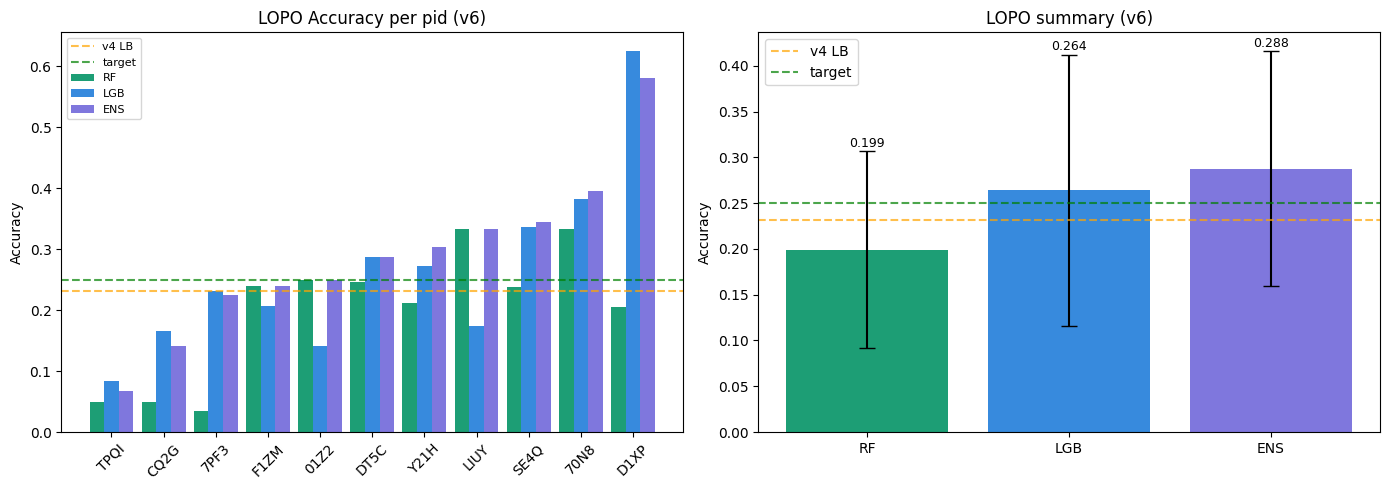

In [12]:
# Plot per-pid accuracy
lopo_df = pd.DataFrame(lopo_pid_results).sort_values('acc_ens')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(lopo_df)); w = 0.28
axes[0].bar(x - w, lopo_df['acc_rf'],  w, label='RF',  color='#1D9E75')
axes[0].bar(x,     lopo_df['acc_lgb'], w, label='LGB', color='#378ADD')
axes[0].bar(x + w, lopo_df['acc_ens'], w, label='ENS', color='#7F77DD')
axes[0].axhline(0.23191, color='orange', ls='--', alpha=0.7, label='v4 LB')
axes[0].axhline(0.25,    color='green',  ls='--', alpha=0.7, label='target')
axes[0].set_xticks(x); axes[0].set_xticklabels(lopo_df['pid'], rotation=45)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('LOPO Accuracy per pid (v6)')
axes[0].legend(fontsize=8)

names  = ['RF','LGB','ENS']
means  = [lopo_df['acc_rf'].mean(), lopo_df['acc_lgb'].mean(), np.mean(lopo_acc)]
stds   = [lopo_df['acc_rf'].std(),  lopo_df['acc_lgb'].std(),  np.std(lopo_acc)]
axes[1].bar(names, means, yerr=stds, color=['#1D9E75','#378ADD','#7F77DD'], capsize=6)
axes[1].axhline(0.23191, color='orange', ls='--', alpha=0.7, label='v4 LB')
axes[1].axhline(0.25,    color='green',  ls='--', alpha=0.7, label='target')
axes[1].set_ylabel('Accuracy'); axes[1].set_title('LOPO summary (v6)'); axes[1].legend()
for i,(m,s) in enumerate(zip(means,stds)):
    axes[1].text(i, m+s+0.005, f'{m:.3f}', ha='center', fontsize=9)

plt.tight_layout(); plt.savefig('lopo_v6.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Final Model Training

Training final model on full training set...

  Class 1 (55): 3 outliers removed
  Class 2 (430): 31 outliers removed
  Class 3 (554): 39 outliers removed
  Class 4 (345): 25 outliers removed
  Class 5 (72): 4 outliers removed
Kept: 1354 / 1456

Selected 67 features

Top 20 features:
      feature  importance
    eda_count    0.071418
    bvp_count    0.068227
    acc_count    0.066312
      eda_min    0.042440
    ibi_count    0.039896
  hr_baseline    0.030502
     ibi_skew    0.029937
 eda_min_lag1    0.029216
temp_baseline    0.024474
eda_mean_lag2    0.019618
hr_delta_lag2    0.015768
     hr_delta    0.015721
 eda_min_lag2    0.012875
 eda_q75_lag2    0.012642
      eda_q75    0.011565
     temp_min    0.011060
 acc_baseline    0.010431
 eda_baseline    0.010003
hr_delta_lag1    0.009935
      bvp_q75    0.009760


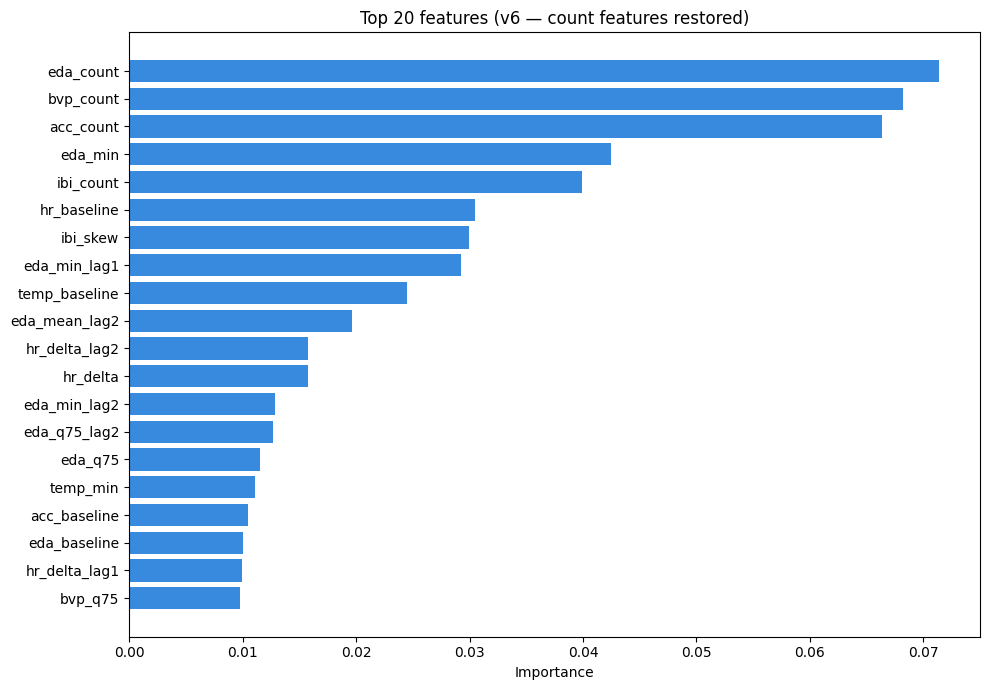

In [13]:
print('Training final model on full training set...\n')

# Outlier removal
X_all = train_base[feat_cols_base].values
y_all = train_base['arousal'].values.astype(int)
outlier_mask_f = np.zeros(len(train_base), dtype=bool)
for cls in np.unique(y_all):
    idx           = np.where(y_all == cls)[0]
    contamination = 0.05 if len(idx) < 100 else 0.07
    iso           = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    preds         = iso.fit_predict(X_all[idx])
    n_out         = np.sum(preds == -1)
    print(f'  Class {cls} ({len(idx)}): {n_out} outliers removed')
    outlier_mask_f[idx[preds == -1]] = True
train_clean = train_base[~outlier_mask_f].copy().reset_index(drop=True)
print(f'Kept: {len(train_clean)} / {len(train_base)}\n')

# Per-pid normalisation on full training set
norm_cols_f = [c for c in feat_cols_base if not c.endswith('_missing')]
train_norm_f = train_clean.copy()
for pid in train_norm_f['pid'].unique():
    m   = train_norm_f['pid'] == pid
    sub = train_norm_f.loc[m, norm_cols_f]
    mu  = sub.mean(); sig = sub.std().replace(0, np.nan)
    train_norm_f.loc[m, norm_cols_f] = (sub - mu) / sig
train_norm_f[norm_cols_f] = train_norm_f[norm_cols_f].fillna(0)

# Feature selection
from sklearn.ensemble import RandomForestRegressor as RFR
rf_sel_f = RFR(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_sel_f.fit(train_norm_f[feat_cols_base].values,
             train_norm_f['arousal'].values.astype(float))
imp_f     = pd.Series(rf_sel_f.feature_importances_, index=feat_cols_base)
final_top = imp_f.nlargest(N_KEEP).index.tolist()
for ind in indicator_cols:
    if ind not in final_top:
        final_top.append(ind)
print(f'Selected {len(final_top)} features\n')

imp_df = pd.DataFrame({'feature': feat_cols_base,
                        'importance': rf_sel_f.feature_importances_}
                      ).sort_values('importance', ascending=False)
print('Top 20 features:')
print(imp_df.head(20).to_string(index=False))

top20 = imp_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#378ADD')
ax.set_title('Top 20 features (v6 — count features restored)')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.savefig('importance_v6.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# ── FIX: Test normalisation — per-pid using test pid's own data ──────────────
# This is valid (no labels used) and was what v4 did correctly.
# v5 broke this by using training global stats, which destroyed test predictions.
test_norm_f = test_df.copy()
for pid in test_norm_f['pid'].unique():
    m   = test_norm_f['pid'] == pid
    sub = test_norm_f.loc[m, norm_cols_f]
    mu  = sub.mean(); sig = sub.std().replace(0, np.nan)
    test_norm_f.loc[m, norm_cols_f] = (sub - mu) / sig
test_norm_f[norm_cols_f] = test_norm_f[norm_cols_f].fillna(0)
print('Test normalised per-pid using test data stats.')

# ADASYN + class weights on full training set
X_train_f = train_norm_f[final_top].values
y_train_f = train_norm_f['arousal'].values.astype(int)

unique_f, counts_f = np.unique(y_train_f, return_counts=True)
print('\nBefore resampling:')
for u, c in zip(unique_f, counts_f): print(f'  Class {u}: {c}')

target_f = {int(cls): max(int(cnt), 150) for cls, cnt in zip(unique_f, counts_f)}
safe_k_f = max(1, min(4, int(min(counts_f)) - 1))
try:
    res_f = ADASYN(sampling_strategy=target_f, n_neighbors=safe_k_f, random_state=42)
    X_res_f, y_res_f = res_f.fit_resample(X_train_f, y_train_f)
    print('ADASYN succeeded.')
except Exception as e:
    print(f'ADASYN failed ({e}), using SMOTE...')
    res_f = SMOTE(sampling_strategy=target_f, k_neighbors=safe_k_f, random_state=42)
    X_res_f, y_res_f = res_f.fit_resample(X_train_f, y_train_f)

print('\nAfter resampling:')
for u, c in zip(*np.unique(y_res_f, return_counts=True)): print(f'  Class {u}: {c}')

cls_counts_f = dict(zip(*np.unique(y_res_f, return_counts=True)))
total_f      = len(y_res_f)
cw_f = {cls: total_f / (len(cls_counts_f) * cnt) for cls, cnt in cls_counts_f.items()}
cw_f[1] = cw_f.get(1, 1.0) * 2.0
cw_f[5] = cw_f.get(5, 1.0) * 2.0
sw_f = np.array([cw_f[y] for y in y_res_f])

print('\nClass weights:')
for k, v in sorted(cw_f.items()): print(f'  Class {k}: {v:.3f}')

Test normalised per-pid using test data stats.

Before resampling:
  Class 1: 52
  Class 2: 399
  Class 3: 515
  Class 4: 320
  Class 5: 68
ADASYN succeeded.

After resampling:
  Class 1: 161
  Class 2: 399
  Class 3: 515
  Class 4: 320
  Class 5: 140

Class weights:
  Class 1: 3.814
  Class 2: 0.769
  Class 3: 0.596
  Class 4: 0.959
  Class 5: 4.386


In [15]:
print('\nFitting final RF Classifier...')
rf_final = RandomForestClassifier(**rf_params)
rf_final.fit(X_res_f, y_res_f, sample_weight=sw_f)
print('  RF done.')

print('Fitting final LGB Classifier...')
lgb_final = lgb.LGBMClassifier(**lgb_params)
lgb_final.fit(X_res_f, y_res_f, sample_weight=sw_f)
print('  LGB done.')

# Ensemble weights: inverse error from LOPO (1 - accuracy)
err_rf  = 1 - np.mean([r['acc_rf']  for r in lopo_pid_results])
err_lgb = 1 - np.mean([r['acc_lgb'] for r in lopo_pid_results])
inv     = np.array([1/err_rf, 1/err_lgb])
w_rf_f, w_lgb_f = inv / inv.sum()
print(f'\nFinal ensemble weights: RF={w_rf_f:.3f}, LGB={w_lgb_f:.3f}')

# Train sanity (in-sample)
prob_tr_rf  = rf_final.predict_proba(X_train_f)
prob_tr_lgb = lgb_final.predict_proba(X_train_f)
prob_tr_ens = w_rf_f * prob_tr_rf + w_lgb_f * prob_tr_lgb
pred_tr     = rf_final.classes_[np.argmax(prob_tr_ens, axis=1)]
print(f'Train accuracy (in-sample, reference only): {accuracy_score(y_train_f, pred_tr):.4f}')
print(f'Honest LOPO accuracy estimate: {np.mean(lopo_acc):.4f}')


Fitting final RF Classifier...
  RF done.
Fitting final LGB Classifier...
  LGB done.

Final ensemble weights: RF=0.479, LGB=0.521
Train accuracy (in-sample, reference only): 0.9874
Honest LOPO accuracy estimate: 0.2877


## 9. Test Predictions

In [16]:
X_test_f = test_norm_f[final_top].values

prob_rf_t  = rf_final.predict_proba(X_test_f)
prob_lgb_t = lgb_final.predict_proba(X_test_f)
prob_ens_t = w_rf_f * prob_rf_t + w_lgb_f * prob_lgb_t
pred_classes_f = rf_final.classes_[np.argmax(prob_ens_t, axis=1)]

print('Prediction distribution:')
for cls in range(1, 6):
    cnt       = (pred_classes_f == cls).sum()
    pct       = cnt / len(pred_classes_f) * 100
    train_pct = (train_labels['arousal'] == cls).mean() * 100
    print(f'  Class {cls}: {cnt:4d} ({pct:.1f}%)  Train {train_pct:.1f}%  Δ={pct-train_pct:+.1f}%')

Prediction distribution:
  Class 1:   96 (6.4%)  Train 3.8%  Δ=+2.6%
  Class 2:  278 (18.6%)  Train 29.5%  Δ=-11.0%
  Class 3:  922 (61.6%)  Train 38.0%  Δ=+23.6%
  Class 4:  184 (12.3%)  Train 23.7%  Δ=-11.4%
  Class 5:   16 (1.1%)  Train 4.9%  Δ=-3.9%


## 10. Generate Submission

In [17]:
submission = pd.DataFrame({
    'id':      test_labels['id'].values,
    'arousal': pred_classes_f,
})

assert len(submission) == len(test_labels)
assert submission['arousal'].between(1, 5).all()
assert (submission['id'] == test_labels['id']).all()

print('Final distribution:')
print(submission['arousal'].value_counts().sort_index())
submission.to_csv('submission_v6.csv', index=False)
print('\nSaved: submission_v6.csv')

print('\n=== Summary ===')
print(f'v3 LB:   0.21437')
print(f'v4 LB:   0.23191  (regression, per-pid test norm)')
print(f'v5 LB:   0.20122  (broke test norm, removed count features)')
print(f'v6 LOPO accuracy: {np.mean(lopo_acc):.4f}  (classifier, per-pid test norm restored)')
print(f'Target:  0.25')

Final distribution:
arousal
1     96
2    278
3    922
4    184
5     16
Name: count, dtype: int64

Saved: submission_v6.csv

=== Summary ===
v3 LB:   0.21437
v4 LB:   0.23191  (regression, per-pid test norm)
v5 LB:   0.20122  (broke test norm, removed count features)
v6 LOPO accuracy: 0.2877  (classifier, per-pid test norm restored)
Target:  0.25
